# Modeling and calibration of aggregate aviation demand for climate mitigation scenarios

This document has been published for reproducing the application presented in the World Conference on Transport Research - WCTR 2026 Toulouse 6-10 July 2026.

The goal of the paper is to review and compare different formulations for modeling long-term aviation demand based on prices and socioeconomic drivers.
The model calibration was performed outside of AeroMAPS, but the calibrated models were then implemented in AeroMAPS and used for simulating the evolution of aviation demand and its related impacts (emissions, climate, costs) under different scenarios.

Each scenario uses population, GDP, and carbon price based on an SSP2 mitigation scenario from the Scenario Database of the 6th IPCC's Assessment Report, with varying target radiative forcing levels by the end of the century. The forcing levels of 1.9 and 2.6 $W/m^2$ being in the range of respect of the Paris Agreement.


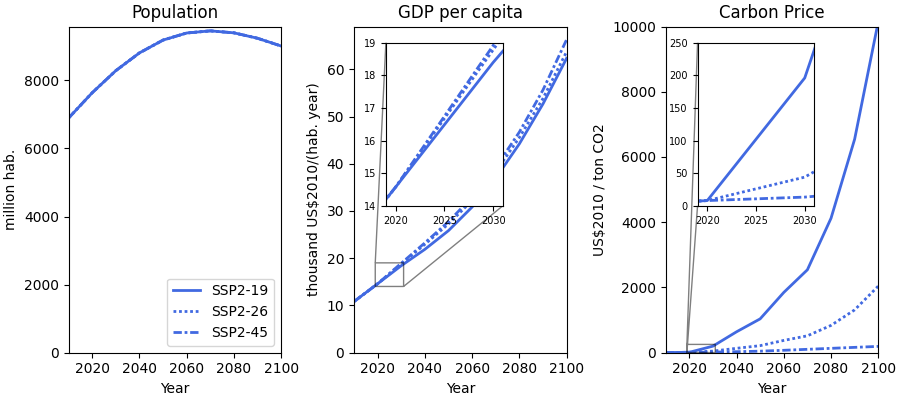

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aeromaps import create_process, assemble_processes
from get_data import get_ar6_input_data

ar6_data, ar6_years = get_ar6_input_data(start_year=2010, end_year=2100, plot_data=True)

In the present context, it is also worthwile to analyse the impact of fluctuations in the jet fuel price based on its historical variation. Especially, since the ongoing war on Iran has raised prices near the max historical value, and the future evolution of the conflict is uncertain.


Kerosene price in 2019: 0.01265556850664434 €/MJ
Minimum historical kerosene price: 0.006263799207652601 €/MJ
Maximum historical kerosene price: 0.022004120442366715 €/MJ


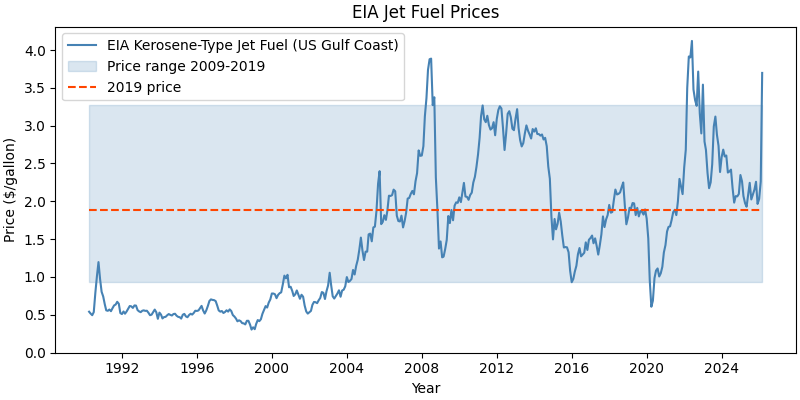

In [2]:
eia_prices = pd.read_csv('./data/eia_jet_fuel_prices.csv', parse_dates=['observation_date'])

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.plot(
    eia_prices['observation_date'],
    eia_prices['MJFUELUSGULF'],
    color='steelblue',
    linewidth=1.5,
    label='EIA Kerosene-Type Jet Fuel (US Gulf Coast)'
)
ax.set_title('EIA Jet Fuel Prices')
ax.set_xlabel('Year')
ax.set_ylabel('Price ($/gallon)')
ax.set_ylim(bottom=0)

kerosene_price_per_gal_2019 = 1.879
eia_prices_2009_2016 = eia_prices[
    (eia_prices['observation_date'].dt.year >= 2009) &
    (eia_prices['observation_date'].dt.year <= 2019)
]
kerosene_price_per_gal_min = eia_prices_2009_2016["MJFUELUSGULF"].min()
kerosene_price_per_gal_max = eia_prices_2009_2016["MJFUELUSGULF"].max()

liter_per_gallon = 3.78541  # L/gal.
kerosene_energy_density = 35.3  # MJ/L
eur_usd_exchange_rate = 0.9  # €/US$

print(f"Kerosene price in 2019: {kerosene_price_per_gal_2019 * eur_usd_exchange_rate / (liter_per_gallon * kerosene_energy_density)} €/MJ")
print(f"Minimum historical kerosene price: {kerosene_price_per_gal_min * eur_usd_exchange_rate / (liter_per_gallon * kerosene_energy_density)} €/MJ")
print(f"Maximum historical kerosene price: {kerosene_price_per_gal_max * eur_usd_exchange_rate / (liter_per_gallon * kerosene_energy_density)} €/MJ")


ax.fill_between(
    eia_prices['observation_date'],
    kerosene_price_per_gal_min,
    kerosene_price_per_gal_max,
    color='steelblue',
    alpha=0.2,
    label='Price range 2009-2019'
)
ax.hlines(
    kerosene_price_per_gal_2019,
    eia_prices['observation_date'].min(),
    eia_prices['observation_date'].max(),
    color='orangered',
    linestyle='--',
    label='2019 price'
)
ax.legend(loc="upper left")
fig.savefig("price_data.pdf")


## 1. Comparison of model formulations

In this first part, we'll compare two model formulations: one based on constant price and income elasticities, and another based on price-adjusted logistic functions (variable income elasticity). While the first is heavily used for prospective analysis, the latter is shown to better fit historical data for the 1990-2019 period.

Both models are compared from 2000 until 2100 considering the SSP2-45 as background scenario (feable carbon tax), and a fossil energy-mix (no SAF incorporation). Furthermore, scenarios are explored with 3 different values for fossil kerosene: minimum historical price, 2019 price, and maximum historical price. The results are compared to the historical evolution of aviation demand and emissions from 2000 to 2019, and future projections.

All the other scenario inputs that are not explicitly mentioned here are kept constant between the different scenarios, and are based on the ICAO LTAG IS2 scenario with a fossil energy-mix (no SAF incorporation).

In [3]:
background_scenario = "SSP2-45"
prices_suffix = ["min", "2019", "max"]
config_files = {
    "Constant income and price elasticities": "./configs/config_elasticity_income_price",
    "Logistic income and price elasticity  ": "./configs/config_logistic_price",
#     "Exogenous growth and price elasticity ": "./configs/config_exogenous_growth_elasticity_price",
}

processes = {}
for name, config in config_files.items():
    for p_name in prices_suffix:
        process = create_process(f"{config}_{p_name}.yaml")

        process.parameters.population_reference_years = ar6_years
        process.parameters.population_reference_years_values = ar6_data["population"][background_scenario]

        process.parameters.gdp_per_capita_reference_years = ar6_years
        process.parameters.gdp_per_capita_reference_years_values = ar6_data["gdp_per_capita"][background_scenario]

        process.parameters.carbon_tax_reference_years = ar6_years
        process.parameters.carbon_tax_reference_years_values = ar6_data["carbon_tax"][background_scenario]

        process.parameters.exogenous_carbon_price_reference_years = ar6_years
        process.parameters.exogenous_carbon_price_reference_years_values = ar6_data["carbon_tax"][background_scenario]

        processes[name + " - " + p_name + " price"] = process
        

processes["Exogenous growth (ICAO LTAG)"] = create_process(f"./configs/config_exogenous_growth.yaml")
        
assembly = assemble_processes(processes)
assembly.compute_all()

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\common\energy_carriers_factory.py:136: UserWarning: 
⚠️ Using Top-Down environmental model for abatement cost. Not recommended.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as bottom-up, using top-down values for CAC computation.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\common\energy_carriers_factory.py:136: UserWarning: 
⚠️ Using Top-Down environmental model for abatement cost. Not recommended.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_mean_co2_emission_factor_without_resource Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (210

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_mean_co2_emission_factor_without_resource Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (210

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The 

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The 

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The 

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_resource_specific_consumption_co2_dac Warning]
The last reference year (2070) is lower than the end year (2100).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: electrofuel_eis_capex Warning]
The last reference year (2070) is lower than the end year (2100).
The valu

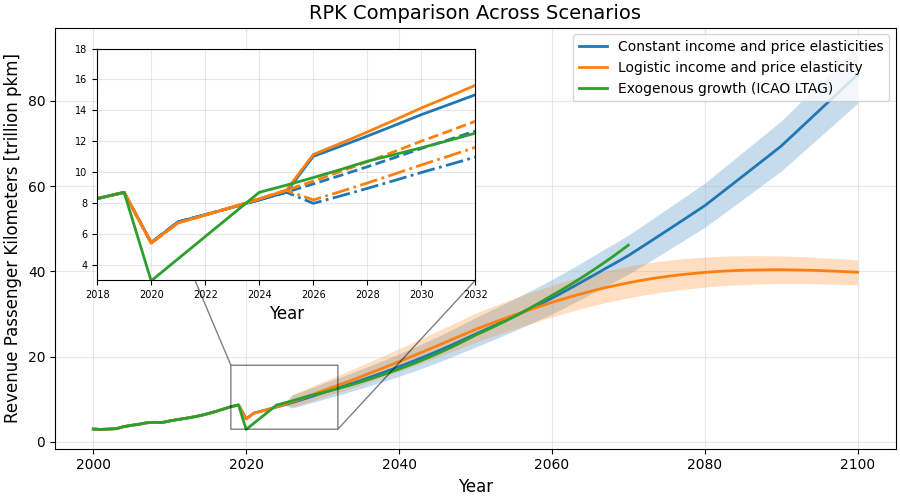

In [4]:
scenario_groups = {
    group_name: [name for name in processes.keys() if group_name in name] for group_name in config_files.keys()
}
scenario_groups["Exogenous growth (ICAO LTAG)"] = ["Exogenous growth (ICAO LTAG)"]
plot_instance = assembly.plot(
    "rpk_comparison", 
    scenario_groups=scenario_groups,
    legend="upper right",
    group_display="envelope",
    
)

ax_inset = plot_instance.ax.inset_axes([0.05, 0.4, 0.45, 0.55])
assembly.plot(
    "rpk_comparison",
    scenario_groups=scenario_groups,
    fig=plot_instance.fig,
    ax=ax_inset,
    legend=False,
)

ax_inset.set_xlim(2018, 2032)
ax_inset.set_ylim(3, 18)
ax_inset.set_ylabel("")
ax_inset.set_title("")
ax_inset.tick_params(labelsize=7)
plot_instance.ax.indicate_inset_zoom(ax_inset, edgecolor="black")
plot_instance.fig.savefig("model_comparison.pdf")

The models based on socioeconomic drivers employ a lag in GDP per-capita between 2019 and 2024 to approximate the behaviour after the COVID-19 pandemic. The fact that the model predicter higher traffic volumes can be explained by the fact that aviation in particular was more affected than the rest of the economy (decrease in per-capita GDP is not sufficient to explain drop in traffic). Near 2024 the traffic levels are slightly lower than observed, this can be attributed to the fact that the SSP scenarios themselves do not account for COVID, and the GDP values provided by these scenarios are different to what was observed in the period.

The model with constant price and income elasticities approximates well ICAO's LTAG traffic forecasts, though the model displays higher growth initially, and lower growth after 2050. The price-adjusted logistic model, pushes these even further, with higher initial growth, and much lower growth after 2050 due to saturation effects.

The sensitivity to kerosene prices is similar for both models as the price differential is applied, but as demand stabilizes in the logistic model so does the gap due to prices. In the constant-elasticities model, as demand is still growing, so is the gap due to prices (multiplicative term on trend demand).

## 2. Comparison with current model

Now, we'll add AeroMAPS current model to the comparison, it assumes an exogenous growth and then corrects this value by the price elasticity.

Studies that estimate price elasticities can yield a wide range of values for this parameter, the standard AeroMAPS value is -0.9 , but in this application we'll employ a different one. As the price-adjusted logistic model estimates an elasticity of -0.266 (relative to fuel costs) and in 2019, fuel represented 24% of airline costs, the total elasticity relative to airfare is estimated to be -1.24

In [5]:
config_files = {
    "Exogenous growth and price elasticity ": "./configs/config_exogenous_growth_elasticity_price",
}

for name, config in config_files.items():
    for p_name in prices_suffix:
        process = create_process(f"{config}_{p_name}.yaml")

        process.parameters.carbon_tax_reference_years = ar6_years
        process.parameters.carbon_tax_reference_years_values = ar6_data["carbon_tax"][background_scenario]

        process.parameters.exogenous_carbon_price_reference_years = ar6_years
        process.parameters.exogenous_carbon_price_reference_years_values = ar6_data["carbon_tax"][background_scenario]
        
        process.compute()
        processes[name + " - " + p_name + " price"] = process
                
assembly2 = assemble_processes(processes)

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\common\energy_carriers_factory.py:136: UserWarning: 
⚠️ Using Top-Down environmental model for abatement cost. Not recommended.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as bottom-up, using top-down values for CAC computation.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: carbon_tax Warning]
The first reference year (2010) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:236: UserWarning: Warning Message - Model name: carbon_tax - Warning on aeromaps_inter

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:236: UserWarning: Warning Message - Model name: exogenous_carbon_price_trajectory - Warning on aeromaps_interpolation_function: The last reference year for the interpolation is higher than end_year, the interpolation function is therefore not used in its entirety.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_electricity_availability_global Warning]
The last reference year (2050) is lower than the end year (2070).
The value associated with the last reference year will be used as a constant for the upper years.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\yaml_interpolator.py:171: UserWarning: 
[Interpolation Model: generic_biomass_availability_global Warning]
The last reference year (2050) is lower than the end year (2070).
The value associated

(3.0, 12.0)

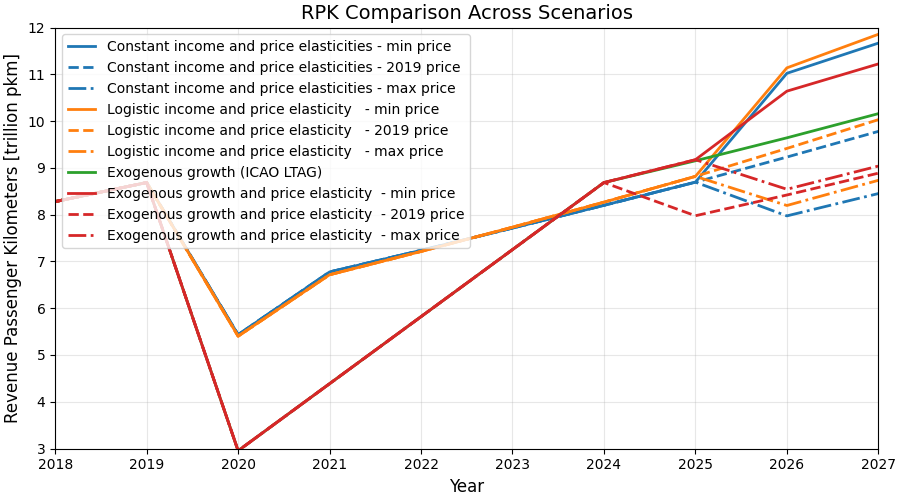

In [6]:
group_name = "Exogenous growth and price elasticity "
scenario_groups[group_name] = [name for name in processes.keys() if group_name in name]

plot_instance_2 = assembly2.plot(
    "rpk_comparison", 
    scenario_groups=scenario_groups,
    legend="upper left",
)
plot_instance_2.ax.set_xlim(2018, 2027)
plot_instance_2.ax.set_ylim(3, 12)


Now, when comparing with the current AeroMAPS elasticity model one can observe that the sensitivity to prices is overestimated when the price differential is applied. This may be due to e fact that the new models use only energy costs as the price proxy, while the current model uses the airfare (which also includes non-energy costs). As the energy prices are affected, their relative change is always greater than the relative change in airfare.

Also, some calibration mismatch is present for the values considered for 2019 prices, which makes the current model deviates from expected behaviour when using 2019 prices.

In [7]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals())